In [1]:
# Package imports
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.autograd import Variable
from torchvision.utils import save_image,make_grid


In [3]:

# MNIST Dataset
train_dataset = datasets.MNIST(root='../torch_tutorial/data', train=True, transform=transforms.ToTensor(), download=True)
test_dataset = datasets.MNIST(root='../torch_tutorial/data/', train=False, transform=transforms.ToTensor(), download=True)


In [4]:
bs=128
# Data Loader
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=bs, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=bs, shuffle=False)

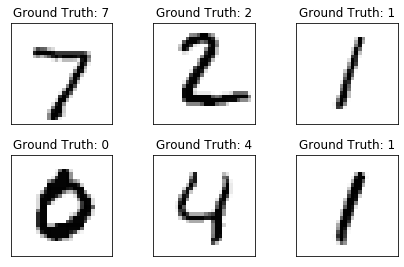

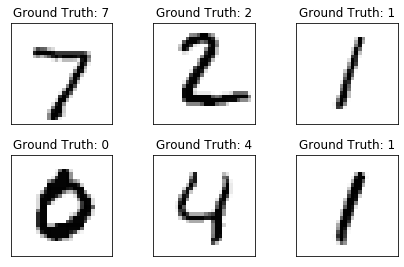

In [22]:
classes = ('0', '1', '2', '3',
           '4', '5', '6', '7', '8', '9')
examples = enumerate(test_loader)
batch_idx, (example_data, example_targets) = next(examples) 
# example_data.shape is torch.Size([128, 1, 28, 28])
# example_targets.shape is torch.Size([128])

fig = plt.figure()
for i in range(6):
  plt.subplot(2,3,i+1)
  plt.tight_layout()
  plt.imshow(1-example_data[i][0], cmap='gray', interpolation='none')
  plt.title("Ground Truth: {}".format(example_targets[i]))
  plt.xticks([])
  plt.yticks([])
fig

In [6]:
example_targets.shape

torch.Size([128])

In [7]:

class CVAE(nn.Module):
    def __init__(self, x_dim, h_dim1, h_dim2, z_dim, class_size):
        super(CVAE, self).__init__()
        
        # encoder
        self.encoder = nn.Sequential(
            nn.Linear(x_dim+class_size, h_dim1),
            nn.LeakyReLU(0.2),
            nn.Linear(h_dim1, h_dim2),
            nn.LeakyReLU(0.2)
            )
        
        # latent mean and variance 
        self.mean_layer = nn.Linear(h_dim2, z_dim)
        self.logvar_layer = nn.Linear(h_dim2, z_dim)
  
        # decoder
        self.decoder = nn.Sequential(
            nn.Linear(z_dim+class_size, h_dim2),
            nn.LeakyReLU(0.2),
            nn.Linear(h_dim2, h_dim1),
            nn.LeakyReLU(0.2),
            nn.Linear(h_dim1, x_dim),
            nn.Sigmoid()
            )
   
    def encode(self, x, c):    #q(z|x,c)
        x = torch.cat([x, c], 1) # (bs, feature_size+class_size)
        x = self.encoder(x)
        mu, log_var = self.mean_layer(x), self.logvar_layer(x)
        return mu, log_var
    
    # sample z from q(z/x) by reparameterization trick
    def reparameterization(self, mu, log_var):
        std = torch.exp(0.5*log_var)
        eps = torch.randn_like(std)
        z = eps.mul(std).add_(mu)
        return z 
  
    def decode(self, z, c):    # p(x|z, c)
        x = torch.cat([z, c], 1) # (bs, latent_size+class_size)
        return self.decoder(x)
   
    def forward(self, x, c):
        mu, log_var = self.encode(x.view(-1, 784), c)
        z = self.reparameterization(mu, log_var)
        y = self.decode(z,c)
        return y, mu, log_var
 

In [23]:
h_dim1 = 512
h_dim2 = 256
z_dim = 2
class_size = 10
model = CVAE(x_dim=784, h_dim1=h_dim1, h_dim2=h_dim2, z_dim=z_dim, class_size=class_size)
if torch.cuda.is_available():
    cvae.cuda()  

In [17]:
def one_hot(labels, class_size):
    targets = torch.zeros(labels.size(0), class_size)
    for i, label in enumerate(labels):
        targets[i, label] = 1
    return targets

In [24]:
optimizer = optim.Adam(model.parameters(), lr=0.001)
# loss_function returns reconstruction error + KL divergence losses
def loss_function(recon_x, x, mu, log_var):
    BCE = F.binary_cross_entropy(recon_x, x.view(-1, 784), reduction='sum')
    KLD = 0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
    return BCE - KLD

In [25]:
def train(epoch):
    model.train()
    train_loss = 0
    for batch_idx, (data, labels) in enumerate(train_loader):
        #data = data.cuda()
        #data, labels = data.to(cpu), labels.to(cup)
        labels = one_hot(labels, 10)
        optimizer.zero_grad()
        
        recon_batch, mu, log_var = model(data,labels)
        loss = loss_function(recon_batch, data, mu, log_var)
        
        loss.backward()
        #train_loss += loss.item()
        optimizer.step()
        
        if batch_idx % 100 == 0:
            print('Epoch {} , Batch {}   \tLoss: {:.6f}'.format(
                epoch, (batch_idx), loss.item() / len(data)))
   

In [26]:
def test(epoch):
    model.eval()
    test_loss= 0
    with torch.no_grad():
        for batch_i, (data, labels) in enumerate(test_loader):
            labels = one_hot(labels,10)
            recon, mu, log_var = model(data, labels)
            
            # sum up batch loss
            #test_loss += loss_function(recon, data, mu, log_var).item()
            test_loss += loss_function(recon, data, mu, log_var).detach().cpu().numpy()
            
            if batch_i == 0:
                n = min(data.size(0), 10)
                comparison = torch.cat([1-data[:n],
                                      1-recon.view(-1, 1, 28, 28)[:n]])
                save_image(comparison.cpu(),
                         './samples/cvae_reconstruction_' + str(f"{epoch:02}") + '.png', nrow=n)

            
        
    test_loss /= len(test_loader.dataset)
    print('=> Test set average loss per batch: {:.4f}'.format(test_loss))





In [27]:
epochs=5
for epoch in range(1, epochs + 1):
        train(epoch)
        test(epoch)
        with torch.no_grad():
            c = torch.eye(10, 10)
            sample = torch.randn(10, z_dim)
            sample = model.decode(sample, c).cpu()
            save_image(1-sample.view(10, 1, 28, 28),
                       './samples/cvae_sample_' + str(f"{epoch:02}") + '.png', nrow=10)

Epoch 1 , Batch 0   	Loss: 543.962341
Epoch 1 , Batch 100   	Loss: 168.704666
Epoch 1 , Batch 200   	Loss: 160.161911
Epoch 1 , Batch 300   	Loss: 152.133163
Epoch 1 , Batch 400   	Loss: 146.557877
=> Test set average loss per batch: 145.2112
Epoch 2 , Batch 0   	Loss: 151.894806
Epoch 2 , Batch 100   	Loss: 148.035095
Epoch 2 , Batch 200   	Loss: 137.344269
Epoch 2 , Batch 300   	Loss: 145.295242
Epoch 2 , Batch 400   	Loss: 139.167969
=> Test set average loss per batch: 139.1607
Epoch 3 , Batch 0   	Loss: 141.007874
Epoch 3 , Batch 100   	Loss: 143.883743
Epoch 3 , Batch 200   	Loss: 140.964523
Epoch 3 , Batch 300   	Loss: 133.254715
Epoch 3 , Batch 400   	Loss: 141.586288
=> Test set average loss per batch: 137.0220
Epoch 4 , Batch 0   	Loss: 137.157715
Epoch 4 , Batch 100   	Loss: 139.264877
Epoch 4 , Batch 200   	Loss: 131.564972
Epoch 4 , Batch 300   	Loss: 137.400604
Epoch 4 , Batch 400   	Loss: 137.187729
=> Test set average loss per batch: 135.4302
Epoch 5 , Batch 0   	Loss: 1